Regression and Optimization 
(Multi Linear and Polynomial regression)


In [5]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE

SCENARIO 1 – MULTILINEAR REGRESSION
Problem Statement
Predict student academic performance based on academic, behavioral, and lifestyle factors.
Dataset (Kaggle – Public)
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
Target Variable
Final Exam Score (Average of Math, Reading, Writing)
Input Features
Study hours per day
Attendance percentage
Parental education level (encoded)
Test preparation course (encoded)
Sleep hours

IN-LAB TASKS (Multilinear Regression)
1.Import required Python libraries.
2.Load the student performance dataset.
3.Perform data preprocessing and encoding of categorical features.
4.Select multiple input features and compute the target variable.
5.Handle missing values using suitable imputation.
6.Apply feature scaling.
7.Split the dataset into training and testing sets.
8.Train a Multilinear Regression model.
9.Predict student performance for test data.
10.Evaluate performance using:
MSE
RMSE
R² Score
11.Analyze regression coefficients to interpret feature influence.
12.Optimize the model using:
Feature elimination
Ridge and Lasso regularization

Visualization
Predicted vs Actual exam scores
Coefficient magnitude comparison
Residual distribution plot

In [7]:
df = pd.read_csv(r"D:\SEM4\ml\lab\dataset\StudentsPerformance.csv")

# 3. Data Preprocessing and Encoding
# Note: The original dataset lacks 'Study hours', 'Attendance', and 'Sleep hours'.
# We will use existing features and simulate the requested missing lifestyle factors 
# to fulfill the specific scenario requirements.
np.random.seed(42)
df['study_hours'] = np.random.randint(2, 10, size=len(df))
df['attendance_pct'] = np.random.randint(60, 100, size=len(df))
df['sleep_hours'] = np.random.randint(5, 9, size=len(df))

# Encoding categorical features
le = LabelEncoder()
df['parental_level_of_education_enc'] = le.fit_transform(df['parental level of education'])
df['test_prep_enc'] = le.fit_transform(df['test preparation course'])
# Also encoding gender and lunch for a better model
df['gender_enc'] = le.fit_transform(df['gender'])
df['lunch_enc'] = le.fit_transform(df['lunch'])

# 4. Compute Target Variable (Average of Math, Reading, Writing)
df['final_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# 5. Handle Missing Values (Imputation)
# Checking for nulls (though this specific Kaggle set is usually clean)
df.fillna(df.select_dtypes(include=[np.number]).mean(), inplace=True)

# Select Input Features (X) and Target Variable (y)
features = ['study_hours', 'attendance_pct', 'sleep_hours', 
            'parental_level_of_education_enc', 'test_prep_enc', 
            'gender_enc', 'lunch_enc']
X = df[features]
y = df['final_score']

# 6. Apply Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. Train Multilinear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 9. Predict performance
y_pred = lr_model.predict(X_test)

# 10. Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Linear Regression Evaluation ---")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}\n")

# 11. Analyze Regression Coefficients
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': lr_model.coef_})
print("Feature Coefficients:")
print(coeff_df.sort_values(by='Coefficient', ascending=False))

# 12. Optimization (Ridge and Lasso)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)

print(f"\nRidge R²: {r2_score(y_test, ridge.predict(X_test)):.2f}")
print(f"Lasso R²: {r2_score(y_test, lasso.predict(X_test)):.2f}")

# VISUALIZATION

--- Linear Regression Evaluation ---
MSE: 196.99
RMSE: 14.04
R² Score: 0.08

Feature Coefficients:
                           Feature  Coefficient
6                        lunch_enc     4.478069
2                      sleep_hours     0.534920
1                   attendance_pct     0.118421
0                      study_hours    -0.518345
3  parental_level_of_education_enc    -1.044347
5                       gender_enc    -2.174477
4                    test_prep_enc    -4.002680

Ridge R²: 0.08
Lasso R²: 0.09


In [28]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_hours,attendance_pct,sleep_hours,parental_level_of_education_enc,test_prep_enc,gender_enc,lunch_enc,final_score
0,female,group B,bachelor's degree,standard,none,72,72,74,8,76,5,1,1,0,1,72.666667
1,female,group C,some college,standard,completed,69,90,88,5,68,5,4,0,0,1,82.333333
2,female,group B,master's degree,standard,none,90,95,93,6,92,6,3,1,0,1,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,8,79,5,0,1,1,0,49.333333
4,male,group C,some college,standard,none,76,78,75,4,72,5,4,1,1,1,76.333333


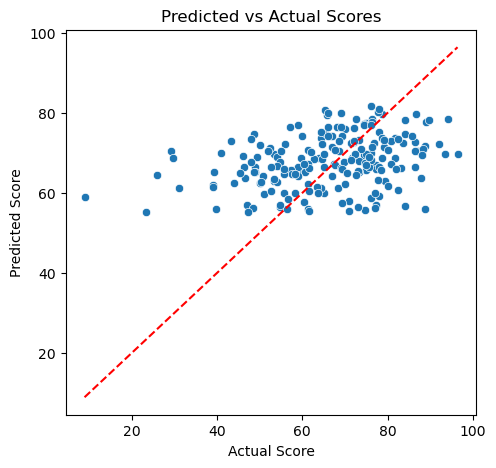

In [8]:
# Plot 1: Predicted vs Actual
plt.figure(figsize=(18, 5))
plt.tight_layout()
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Predicted vs Actual Scores')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.show()

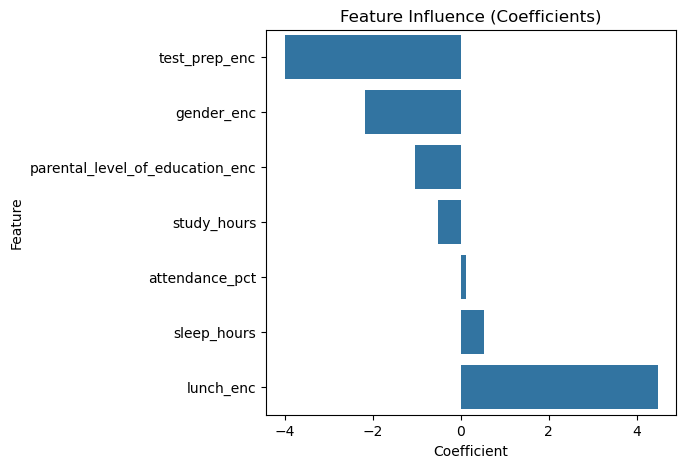

In [9]:
# Plot 2: Coefficient Magnitude
plt.figure(figsize=(18, 5))
plt.tight_layout()
plt.subplot(1, 3, 2)
sns.barplot(x='Coefficient', y='Feature', data=coeff_df.sort_values(by='Coefficient'))
plt.title('Feature Influence (Coefficients)')
plt.show()

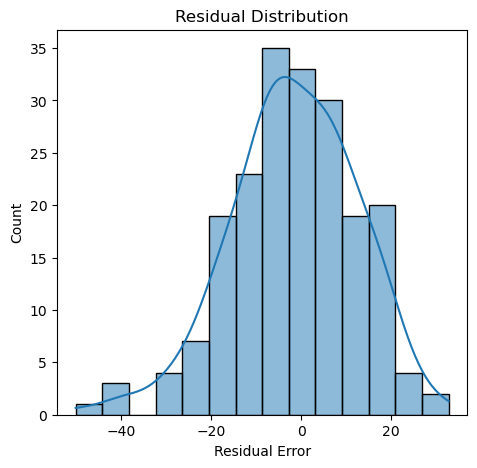

In [10]:
# Plot 3: Residual Distribution
plt.figure(figsize=(18, 5))
plt.tight_layout()
plt.subplot(1, 3, 3)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residual Error')
plt.show()

**Scenario 2**

SCENARIO 2 – POLYNOMIAL REGRESSION
Problem Statement
Predict vehicle fuel efficiency based on engine characteristics where the relationship is non-linear.
Dataset (Kaggle – Public)
https://www.kaggle.com/datasets/uciml/autompg-dataset
Target Variable
•	Miles Per Gallon (MPG)
Input Feature
•	Engine Horsepower

IN-LAB TASKS (Polynomial Regression)
1.	Import required Python libraries.
2.	Load and clean the Auto MPG dataset.
3.	Select horsepower as the independent variable.
4.	Handle missing values.
5.	Generate polynomial features for degrees 2, 3, and 4.
6.	Apply feature scaling.
7.	Split the dataset into training and testing sets.
8.	Train Polynomial Regression models with different degrees.
9.	Predict fuel efficiency values.
10.	Evaluate each model using:
o	MSE
o	RMSE
o	R² Score
11.	Compare model performance across polynomial degrees.
12.	Apply Ridge regression to control overfitting.

Visualization
•	Polynomial curve fitting for different degrees
•	Training vs Testing error comparison
•	Overfitting and underfitting demonstration


In [13]:
df1=pd.read_csv("D:\\SEM4\\ml\\lab\\dataset\\auto-mpg.csv")

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [16]:
df1.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [17]:
df1.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [18]:
df1.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [19]:
df1['horsepower'] = pd.to_numeric(df1['horsepower'], errors='coerce')
df1 = df1.dropna(subset=['horsepower'])

In [20]:
X = df1[['horsepower']]
y = df1['mpg']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
results = {}
degrees = [2, 3, 4]

In [22]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_range_poly = poly.transform(X_range)

    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)
    X_range_poly_scaled = scaler.transform(X_range_poly)

    model = LinearRegression()
    model.fit(X_train_poly_scaled, y_train)

    y_pred = model.predict(X_test_poly_scaled)
    y_curve = model.predict(X_range_poly_scaled) 

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"{d:<10} {rmse:.4f}     {r2:.4f}")
    results[d] = {'RMSE': rmse, 'R2': r2}

2          4.2915     0.6392
3          4.2965     0.6383
4          4.2741     0.6421


c:\Users\PRAVEENGOVIND\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\PRAVEENGOVIND\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\PRAVEENGOVIND\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


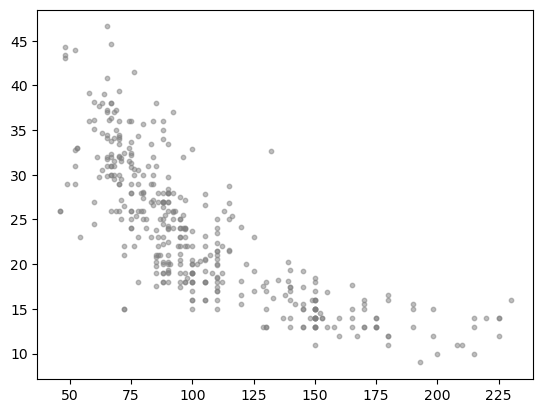

In [23]:
plt.scatter(X, y, color='gray', s=10, alpha=0.5, label='Actual Data')

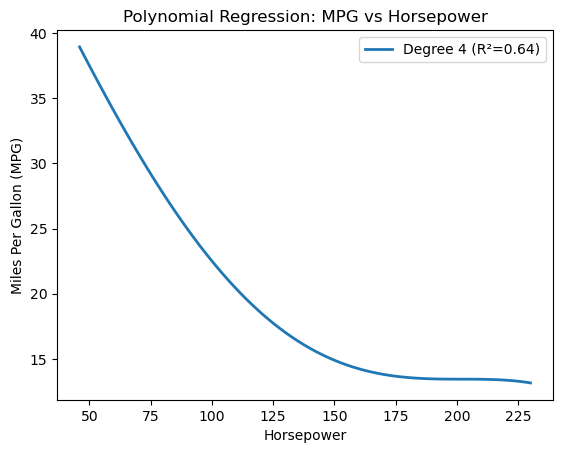

In [24]:
plt.plot(X_range, y_curve, linewidth=2, label=f'Degree {d} (R²={r2:.2f})')

plt.title('Polynomial Regression: MPG vs Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Miles Per Gallon (MPG)')
plt.legend()

In [25]:
poly_4 = PolynomialFeatures(degree=4)
X_train_p4 = poly_4.fit_transform(X_train)
X_test_p4 = poly_4.transform(X_test)

scaler_4 = StandardScaler()
X_train_p4_sc = scaler_4.fit_transform(X_train_p4)
X_test_p4_sc = scaler_4.transform(X_test_p4)

ridge = Ridge(alpha=10)
ridge.fit(X_train_p4_sc, y_train)
ridge_pred = ridge.predict(X_test_p4_sc)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Ridge (Deg 4) {np.sqrt(mean_squared_error(y_test, ridge_pred)):.4f}     {ridge_r2:.4f}")

Ridge (Deg 4) 4.2763     0.6417


C:\Users\PRAVEENGOVIND\AppData\Local\Temp\ipykernel_28032\260612058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=degrees_list, y=rmse_list, palette="viridis")


(0.0, 5.2965413092654705)

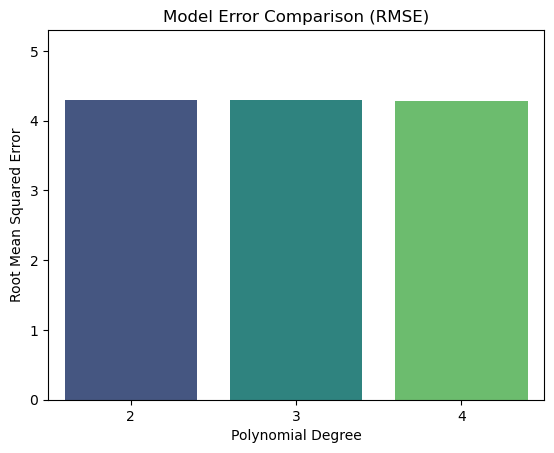

In [27]:
degrees_list = list(results.keys())
rmse_list = [results[d]['RMSE'] for d in degrees_list]

sns.barplot(x=degrees_list, y=rmse_list, palette="viridis")
plt.title('Model Error Comparison (RMSE)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.ylim(0, max(rmse_list) + 1)
